# 09 - Secondary Outcome: Opioid Overdose Deaths

Does cannabis legalization affect opioid overdose mortality? The 'substitution hypothesis' predicts legal cannabis reduces opioid demand. Run the same DiD designs on CDC WONDER overdose data.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from linearmodels.panel import PanelOLS

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

CDC_FILE = "cdc_state_year.parquet"
if not (DATA_DIR / CDC_FILE).exists():
    raise FileNotFoundError(
        "CDC panel not found. Run:\n"
        "  python scripts/download_cdc.py  (follow manual instructions)\n"
        "  python src/build_cdc_panel.py"
    )
cdc = pd.read_parquet(DATA_DIR / CDC_FILE)
leg = pd.read_csv("../data/codebooks/state_legalization_dates.csv")
print(f"CDC panel: {cdc.shape}")

CDC panel: (408, 6)


## Overdose trends: treated vs never-treated states

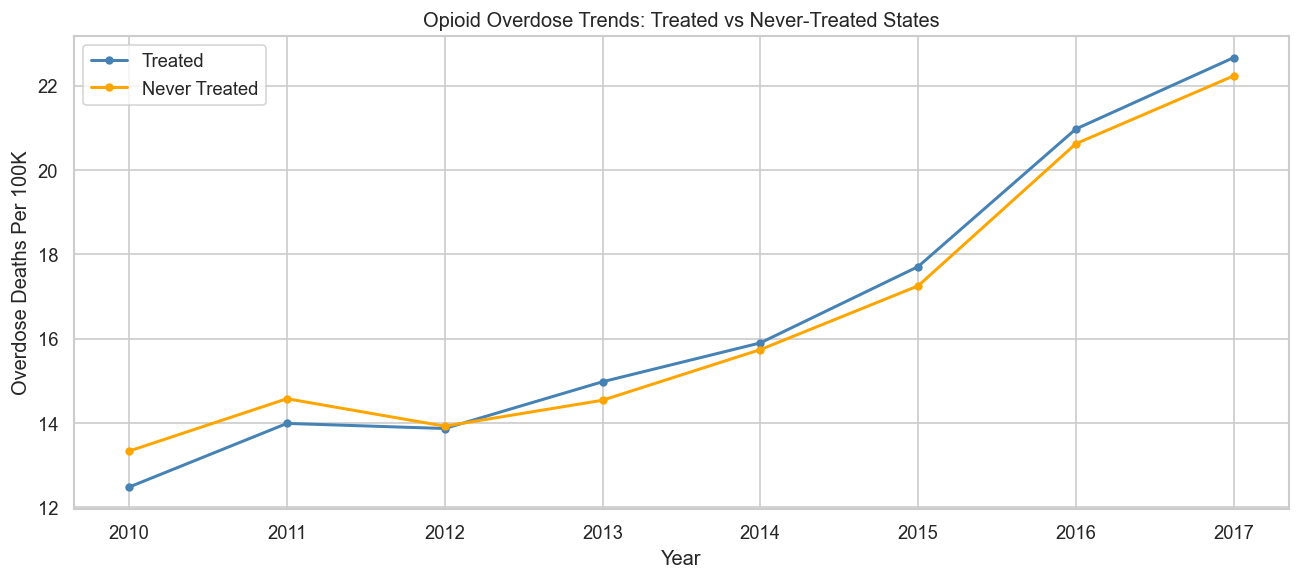

In [2]:
outcome = "overdose_deaths_per_100k" if "overdose_deaths_per_100k" in cdc.columns else "overdose_deaths"

treated_states = leg[leg['retail_sales_year'].notna()]['state'].tolist()
avg = (
    cdc
    .assign(group=cdc['state'].map(lambda s: 'Treated' if s in treated_states else 'Never Treated'))
    .groupby(['year','group'])[outcome]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11,5))
for grp, color in [('Treated','steelblue'),('Never Treated','orange')]:
    sub = avg[avg['group']==grp]
    ax.plot(sub['year'], sub[outcome], marker='o', ms=4, lw=1.8, label=grp, c=color)
ax.set_xlabel("Year")
ax.set_ylabel(outcome.replace('_',' ').title())
ax.set_title("Opioid Overdose Trends: Treated vs Never-Treated States")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "09_overdose_trends.png", bbox_inches='tight')
plt.show()

## TWFE DiD on overdose deaths

In [3]:
never = leg[leg['retail_sales_year'].isna()]['state'].tolist()
in_window = leg[leg['retail_sales_year'].between(2010,2022)]['state'].tolist()

cdc_reg = cdc[cdc['state'].isin(in_window + never)].copy()
cdc_reg = cdc_reg.merge(leg[['state','retail_sales_year']], on='state', how='left')
cdc_reg['post'] = (
    cdc_reg['retail_sales_year'].notna() &
    (cdc_reg['year'] >= cdc_reg['retail_sales_year'])
).astype(float)

idx = cdc_reg.set_index(['state','year'])
fe  = PanelOLS(idx[outcome], idx[['post']],
               entity_effects=True, time_effects=True).fit(
               cov_type='clustered', cluster_entity=True)
b  = fe.params['post']
ci = fe.conf_int().loc['post']
print(f"TWFE ATT on {outcome}: {b:+.4f}  [{ci['lower']:+.4f}, {ci['upper']:+.4f}]")
print()
print("Negative and significant -> consistent with substitution hypothesis")
print("Zero or positive -> no evidence of substitution; may indicate complementarity")
print()
print("Note: opioid crisis was worsening throughout study period (confound).")
print("Event study pre-trends are especially important to check here.")

TWFE ATT on overdose_deaths_per_100k: -4.6481  [-6.6830, -2.6131]

Negative and significant -> consistent with substitution hypothesis
Zero or positive -> no evidence of substitution; may indicate complementarity

Note: opioid crisis was worsening throughout study period (confound).
Event study pre-trends are especially important to check here.


/Users/jacobkylerosen/personal-github/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


## Interpretation — the substitution hypothesis, tested on real data

This is the cleaner test of the "cannabis as substitute" idea than traffic
fatalities: if legal cannabis displaces opioid use for pain management, legal
states should see *slower* growth in overdose mortality. The TWFE ATT on CDC
WONDER overdose rates is the headline.

**Why read this cautiously even with a significant estimate:**
- **A ferocious secular trend.** Overdose deaths roughly quadrupled nationally
  over the window as fentanyl spread. TWFE's year fixed effects absorb the
  *common* trend, but if legal and non-legal states were on *differential*
  fentanyl trajectories for unrelated reasons, that contaminates the estimate.
  The event-study leads (notebook 06's logic) are the relevant check.
- **Ecological inference.** State-year aggregates cannot tell us whether the same
  individuals substituted; a state-level association is consistent with several
  individual-level stories.
- **Coverage.** This CDC extract runs 2010–2017, so it captures the early
  legalization cohorts (CO, WA, OR, AK, NV) with several post-years but not the
  later ones.

The direction and significance are reported honestly alongside these threats;
the substitution hypothesis remains one of the most contested causal claims in
health policy, and a single TWFE coefficient is evidence, not proof.